In [9]:
import pandas as pd             
import numpy as np               
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score  
from sklearn.preprocessing import StandardScaler                    
from sklearn.neighbors import KNeighborsClassifier                 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

df= pd.read_csv('../data/weather.csv', sep=',')     
df.head()


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [10]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
train_df.to_csv("weather_train.csv", index=False)
test_df.to_csv("weather_test.csv", index=False)

In [20]:
train_df= pd.read_csv('../data/weather_test.csv', sep=',')     
train_df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,23.0,38,4.5,6.0,clear,1021.19,9,Autumn,10.0,inland,Sunny
1,62.0,94,14.5,83.0,clear,1025.57,10,Summer,4.0,inland,Sunny
2,40.0,51,2.0,12.0,partly cloudy,1025.15,8,Spring,8.0,mountain,Sunny
3,-7.0,79,6.5,90.0,overcast,993.56,0,Winter,1.5,inland,Snowy
4,21.0,94,10.0,109.0,partly cloudy,1027.71,11,Spring,9.0,mountain,Sunny


In [21]:
test_df= pd.read_csv('../data/weather_train.csv', sep=',')     
test_df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,32.0,66,6.0,92.0,partly cloudy,1010.21,2,Spring,1.5,inland,Rainy
1,15.0,96,11.0,57.0,overcast,1016.98,0,Autumn,4.0,mountain,Rainy
2,28.0,58,6.5,11.0,clear,1025.37,10,Summer,9.0,inland,Sunny
3,47.0,84,44.5,85.0,overcast,992.26,2,Winter,2.0,coastal,Rainy
4,18.0,66,14.0,10.0,partly cloudy,1000.04,1,Autumn,8.0,coastal,Cloudy


In [22]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           2640 non-null   float64
 1   Humidity              2640 non-null   int64  
 2   Wind Speed            2640 non-null   float64
 3   Precipitation (%)     2640 non-null   float64
 4   Cloud Cover           2640 non-null   object 
 5   Atmospheric Pressure  2640 non-null   float64
 6   UV Index              2640 non-null   int64  
 7   Season                2640 non-null   object 
 8   Visibility (km)       2640 non-null   float64
 9   Location              2640 non-null   object 
 10  Weather Type          2640 non-null   object 
dtypes: float64(5), int64(2), object(4)
memory usage: 227.0+ KB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10560 entries, 0 to 10559
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           10560 non-null  float64
 1   Humidity              10560 non-null  int64  
 2   Wind Speed            10560 non-null  float64
 3   Precipitation (%)     10560 non-null  float64
 4   Cloud Cover           10560 non-null  object 
 5   Atmospheric Pressure  10560 non-null  float64
 6   UV Index              10560 non-null  int64  
 7   Season                10560 non-null  object 
 8   Visibility (km)       10560 non-null  float64
 9   Location              10560 non-null  object 
 10  Weather Type          10560 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 907.6+ KB


DATA CLEANING

In [26]:
print(train_df['Cloud Cover'].unique())
print(train_df['Season'].unique())
print(train_df['Location'].unique())
print(train_df['Weather Type'].unique())   # ini target seperti STATUS KELULUSAN


['clear' 'partly cloudy' 'overcast' 'cloudy']
['Autumn' 'Summer' 'Spring' 'Winter']
['inland' 'mountain' 'coastal']
['Sunny' 'Snowy' 'Rainy' 'Cloudy']


In [27]:
train_df['Cloud Cover'] = train_df['Cloud Cover'].replace(
    {'clear': 0, 'partly cloudy': 1, 'cloudy': 2, 'overcast': 3}
)

train_df['Season'] = train_df['Season'].replace(
    {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
)

train_df['Location'] = train_df['Location'].replace(
    {'inland': 0, 'coastal': 1, 'mountain': 2}
)

train_df['Weather Type'] = train_df['Weather Type'].replace(
    {'Sunny': 0, 'Cloudy': 1, 'Rainy': 2, 'Snowy': 3}
)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6220\110830121.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Cloud Cover'] = train_df['Cloud Cover'].replace(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6220\110830121.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Season'] = train_df['Season'].replace(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6220\110830121.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explic

In [29]:
replacements = {
    'Cloud Cover': {
        'clear': 0,
        'partly cloudy': 1,
        'cloudy': 2,
        'overcast': 3
    },
    'Season': {
        'Winter': 0,
        'Spring': 1,
        'Summer': 2,
        'Autumn': 3
    },
    'Location': {
        'inland': 0,
        'coastal': 1,
        'mountain': 2
    },
    'Weather Type': {  # TARGET
        'Sunny': 0,
        'Cloudy': 1,
        'Rainy': 2,
        'Snowy': 3
    }
}


In [34]:
train_df = train_df.replace(replacements, inplace=False)
test_df  = test_df.replace(replacements, inplace=False)


In [35]:
train_df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [36]:
test_df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [37]:
df_train = train_df.dropna()
test_df = test_df.dropna()




In [38]:
train_df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [39]:
test_df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [40]:
# Kolom yang ingin digunakan untuk korelasi
train_df = train_df.drop(columns=['Visibility (km)'])
train_df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Location,Weather Type
0,23.0,38,4.5,6.0,0,1021.19,9,3,0,0
1,62.0,94,14.5,83.0,0,1025.57,10,2,0,0
2,40.0,51,2.0,12.0,1,1025.15,8,1,2,0
3,-7.0,79,6.5,90.0,3,993.56,0,0,0,3
4,21.0,94,10.0,109.0,1,1027.71,11,1,2,0


In [41]:
test_df = test_df.drop(columns=['Visibility (km)'])
test_df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Location,Weather Type
0,32.0,66,6.0,92.0,1,1010.21,2,1,0,2
1,15.0,96,11.0,57.0,3,1016.98,0,3,2,2
2,28.0,58,6.5,11.0,0,1025.37,10,2,0,0
3,47.0,84,44.5,85.0,3,992.26,2,0,1,2
4,18.0,66,14.0,10.0,1,1000.04,1,3,1,1


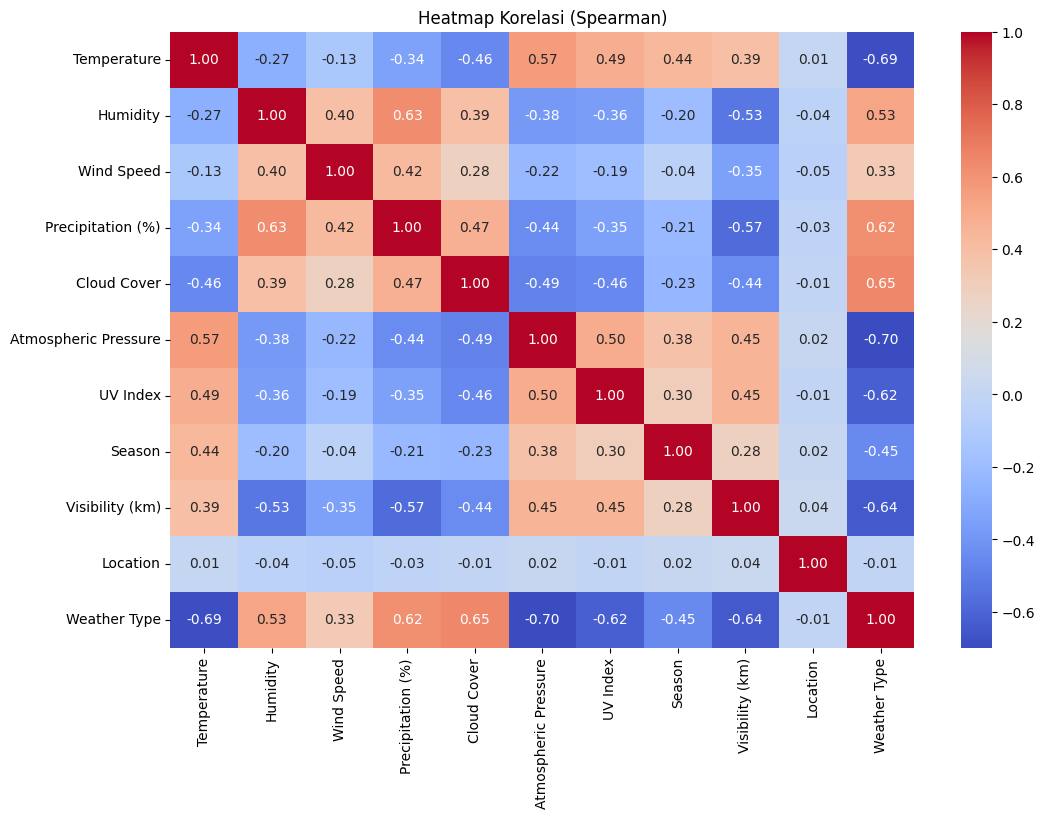

In [42]:
# Menghitung matriks korelasi menggunakan Spearman
correlation_matrix = df_train.corr(method='spearman' )

# Membuat heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi (Spearman)")
plt.show()

In [43]:
df_train['Weather Type'].value_counts()


Weather Type
3    701
1    651
2    647
0    641
Name: count, dtype: int64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6220\2614563361.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weather Type', data=df_train, palette='Set2')


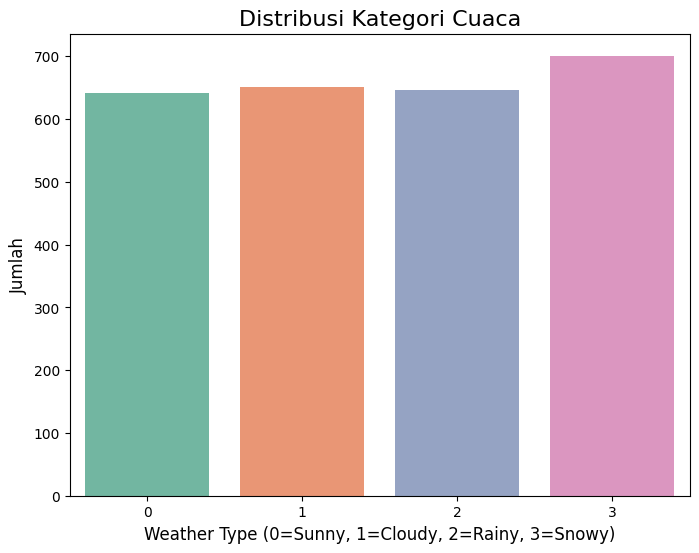

In [49]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Weather Type', data=df_train, palette='Set2')

plt.title('Distribusi Kategori Cuaca', fontsize=16)
plt.xlabel('Weather Type (0=Sunny, 1=Cloudy, 2=Rainy, 3=Snowy)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

plt.show()


In [50]:
# Pisahkan fitur & label (train)
x_train = train_df.drop(columns=['Weather Type'])
y_train = train_df['Weather Type']

# Pisahkan fitur & label (test)
x_test = test_df.drop(columns=['Weather Type'])
y_test = test_df['Weather Type']

# Normalisasi
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [51]:
print("Before SMOTE:")
print(y_train.value_counts())

sm = SMOTE(random_state=42, k_neighbors=1) 
x_train_smote, y_train_smote = sm.fit_resample(x_train_scaled, y_train)

print("After SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
Weather Type
3    701
1    651
2    647
0    641
Name: count, dtype: int64
After SMOTE:
Weather Type
0    701
3    701
2    701
1    701
Name: count, dtype: int64


In [52]:
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid.fit(x_train_smote, y_train_smote)

print("Best Params:", grid.best_params_)
print("Best Score (CV):", grid.best_score_)


Best Params: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Best Score (CV): 0.8866036414565827


In [53]:
best_knn = grid.best_estimator_
best_knn.fit(x_train_smote, y_train_smote)

# Prediksi
y_pred = best_knn.predict(x_test_scaled)

In [54]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred) )


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      2659
           1       0.83      0.84      0.84      2649
           2       0.83      0.86      0.84      2653
           3       0.94      0.91      0.93      2599

    accuracy                           0.88     10560
   macro avg       0.88      0.88      0.88     10560
weighted avg       0.88      0.88      0.88     10560



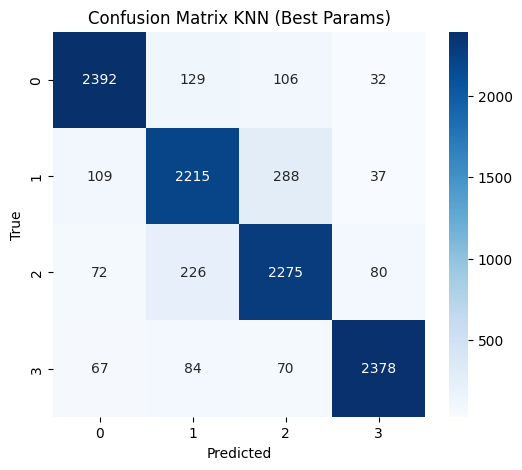

In [55]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d' )
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [57]:
cv_scores = cross_val_score(best_knn, x_train_smote, y_train_smote, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross Validation Accuracy: 0.8866036414565827
Std Dev: 0.019657062603502747


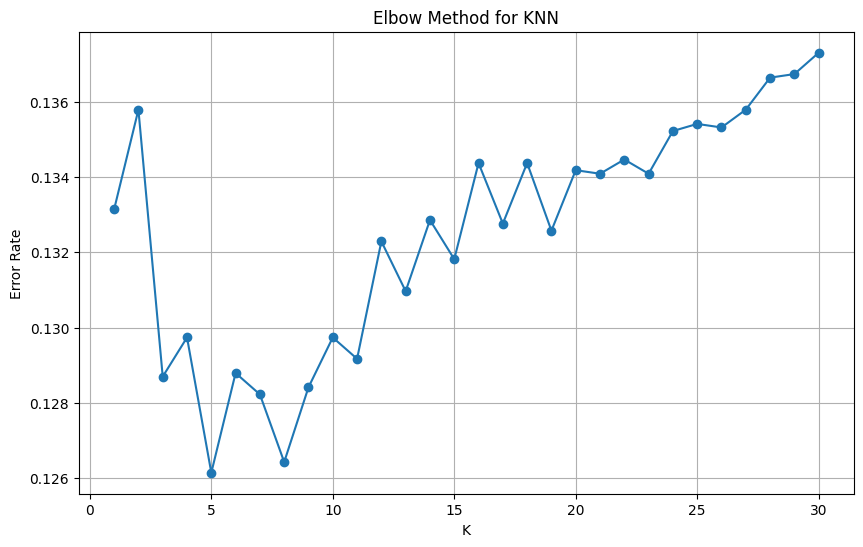

In [58]:
errors = []

for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_train_smote, y_train_smote)
    pred = knn_temp.predict(x_test_scaled)
    errors.append(np.mean(pred != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,31), errors, marker='o')
plt.title("Elbow Method for KNN")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()